In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score, classification_report
from lightgbm import LGBMClassifier
from sklearn.dummy import DummyClassifier
from lightgbm import LGBMRegressor
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [5]:
data = pd.read_csv("ai_student_impact_dataset (1).csv")

In [6]:
data.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4.0,3.798,100.0,Medium
1,100151,Medical,Freshman,3.850,20.40,Copywriting/Drafting,Beginner,1,False,16.51,6,Actively_Encouraged,6.0,4.000,100.0,Medium
2,100193,Medical,Sophomore,3.282,2.41,Direct_Answer_Generation,Beginner,2,False,12.17,3,Allowed_With_Citation,1.0,3.661,100.0,Low
3,100237,STEM,Freshman,3.291,8.76,Copywriting/Drafting,Intermediate,3,True,16.54,2,Strict_Ban,3.0,3.644,100.0,Medium
4,100238,STEM,Junior,3.857,3.97,Direct_Answer_Generation,Advanced,4,False,23.89,1,Allowed_With_Citation,4.0,4.000,100.0,Medium


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26553 entries, 0 to 26552
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  26553 non-null  int64  
 1   Major_Category              26553 non-null  object 
 2   Year_of_Study               26553 non-null  object 
 3   Pre_Semester_GPA            26553 non-null  float64
 4   Weekly_GenAI_Hours          26553 non-null  float64
 5   Primary_Use_Case            26553 non-null  object 
 6   Prompt_Engineering_Skill    26553 non-null  object 
 7   Tool_Diversity              26553 non-null  int64  
 8   Paid_Subscription           26553 non-null  bool   
 9   Traditional_Study_Hours     26553 non-null  float64
 10  Perceived_AI_Dependency     26553 non-null  int64  
 11  Institutional_Policy        26553 non-null  object 
 12  Anxiety_Level_During_Exams  26552 non-null  float64
 13  Post_Semester_GPA           265

In [8]:
data.isnull().sum()

,0
Student_ID,0
Major_Category,0
Year_of_Study,0
Pre_Semester_GPA,0
Weekly_GenAI_Hours,0
Primary_Use_Case,0
Prompt_Engineering_Skill,0
Tool_Diversity,0
Paid_Subscription,0
Traditional_Study_Hours,0


In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
numerical_features = data.select_dtypes(include=['number'])

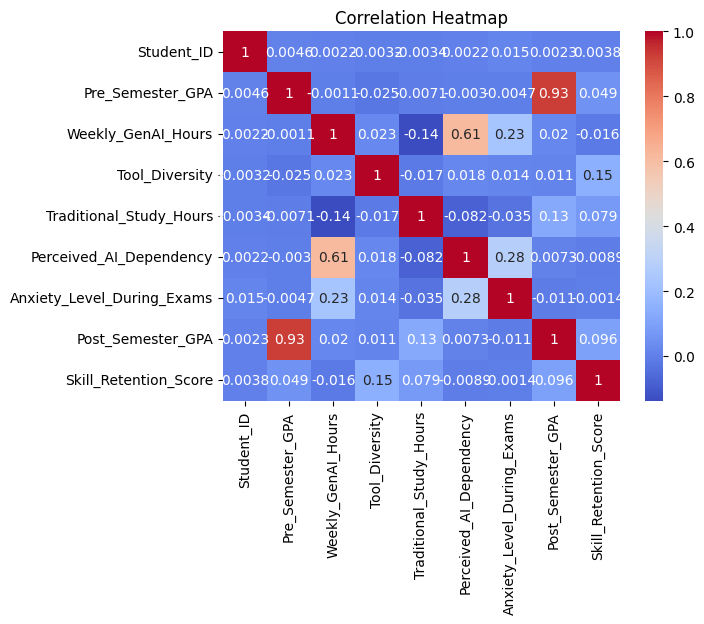

In [11]:
corr = numerical_features.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [12]:
numerical_features.drop(columns=['Student_ID'], errors='ignore', inplace=True)

In [13]:
nf_updated = numerical_features

In [14]:
nf_updated['GPA_Difference'] = nf_updated['Post_Semester_GPA'] - nf_updated['Pre_Semester_GPA']
display(nf_updated.head())

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,GPA_Difference
0,3.635,9.29,4,12.55,4,4.0,3.798,100.0,0.163
1,3.850,20.40,1,16.51,6,6.0,4.000,100.0,0.150
2,3.282,2.41,2,12.17,3,1.0,3.661,100.0,0.379
3,3.291,8.76,3,16.54,2,3.0,3.644,100.0,0.353
4,3.857,3.97,4,23.89,1,4.0,4.000,100.0,0.143


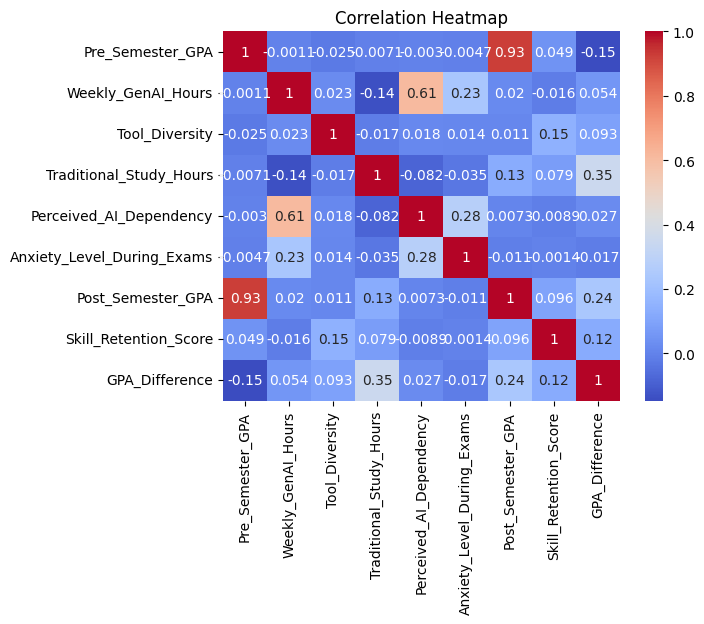

In [15]:
corr = nf_updated.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [16]:
nf_updated.drop(columns=['Pre_Semester_GPA','Post_Semester_GPA'], errors='ignore', inplace=True)

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = nf_updated.columns

vif_data["VIF"] = [variance_inflation_factor(nf_updated.values, i) for i in range(nf_updated.shape[1])]

display(vif_data.sort_values(by="VIF", ascending=False))

MissingDataError: exog contains inf or nans

In [18]:
nf_updated['Study_Balance'] = nf_updated['Traditional_Study_Hours'] - nf_updated['Weekly_GenAI_Hours']
display(nf_updated.head())

,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Skill_Retention_Score,GPA_Difference,Study_Balance
0,9.29,4,12.55,4,4.0,100.0,0.163,3.26
1,20.40,1,16.51,6,6.0,100.0,0.150,-3.89
2,2.41,2,12.17,3,1.0,100.0,0.379,9.76
3,8.76,3,16.54,2,3.0,100.0,0.353,7.78
4,3.97,4,23.89,1,4.0,100.0,0.143,19.92


In [19]:
nf_updated.drop(columns=['Traditional_Study_Hours', 'Weekly_GenAI_Hours'], inplace=True)
display(nf_updated.head())

,Tool_Diversity,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Skill_Retention_Score,GPA_Difference,Study_Balance
0,4,4,4.0,100.0,0.163,3.26
1,1,6,6.0,100.0,0.150,-3.89
2,2,3,1.0,100.0,0.379,9.76
3,3,2,3.0,100.0,0.353,7.78
4,4,1,4.0,100.0,0.143,19.92


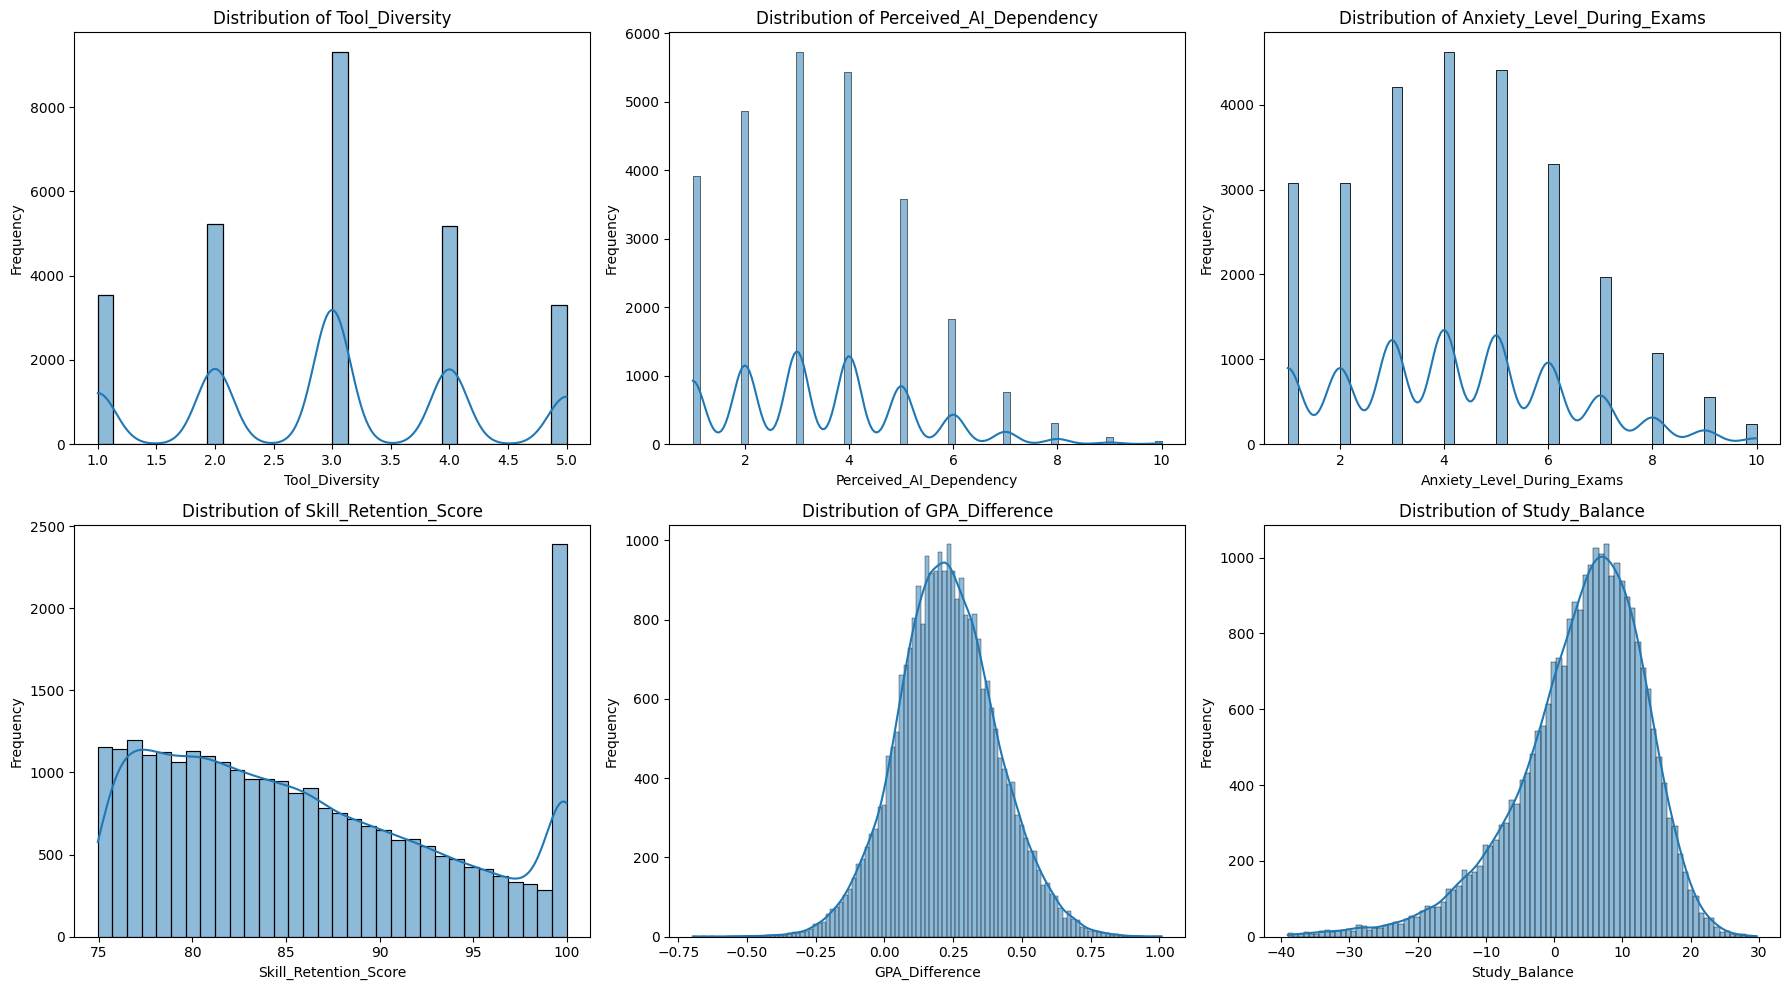

In [20]:
num_features = nf_updated.shape[1]
num_cols = 3
num_rows = (num_features + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(nf_updated.columns):
    sns.histplot(nf_updated[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

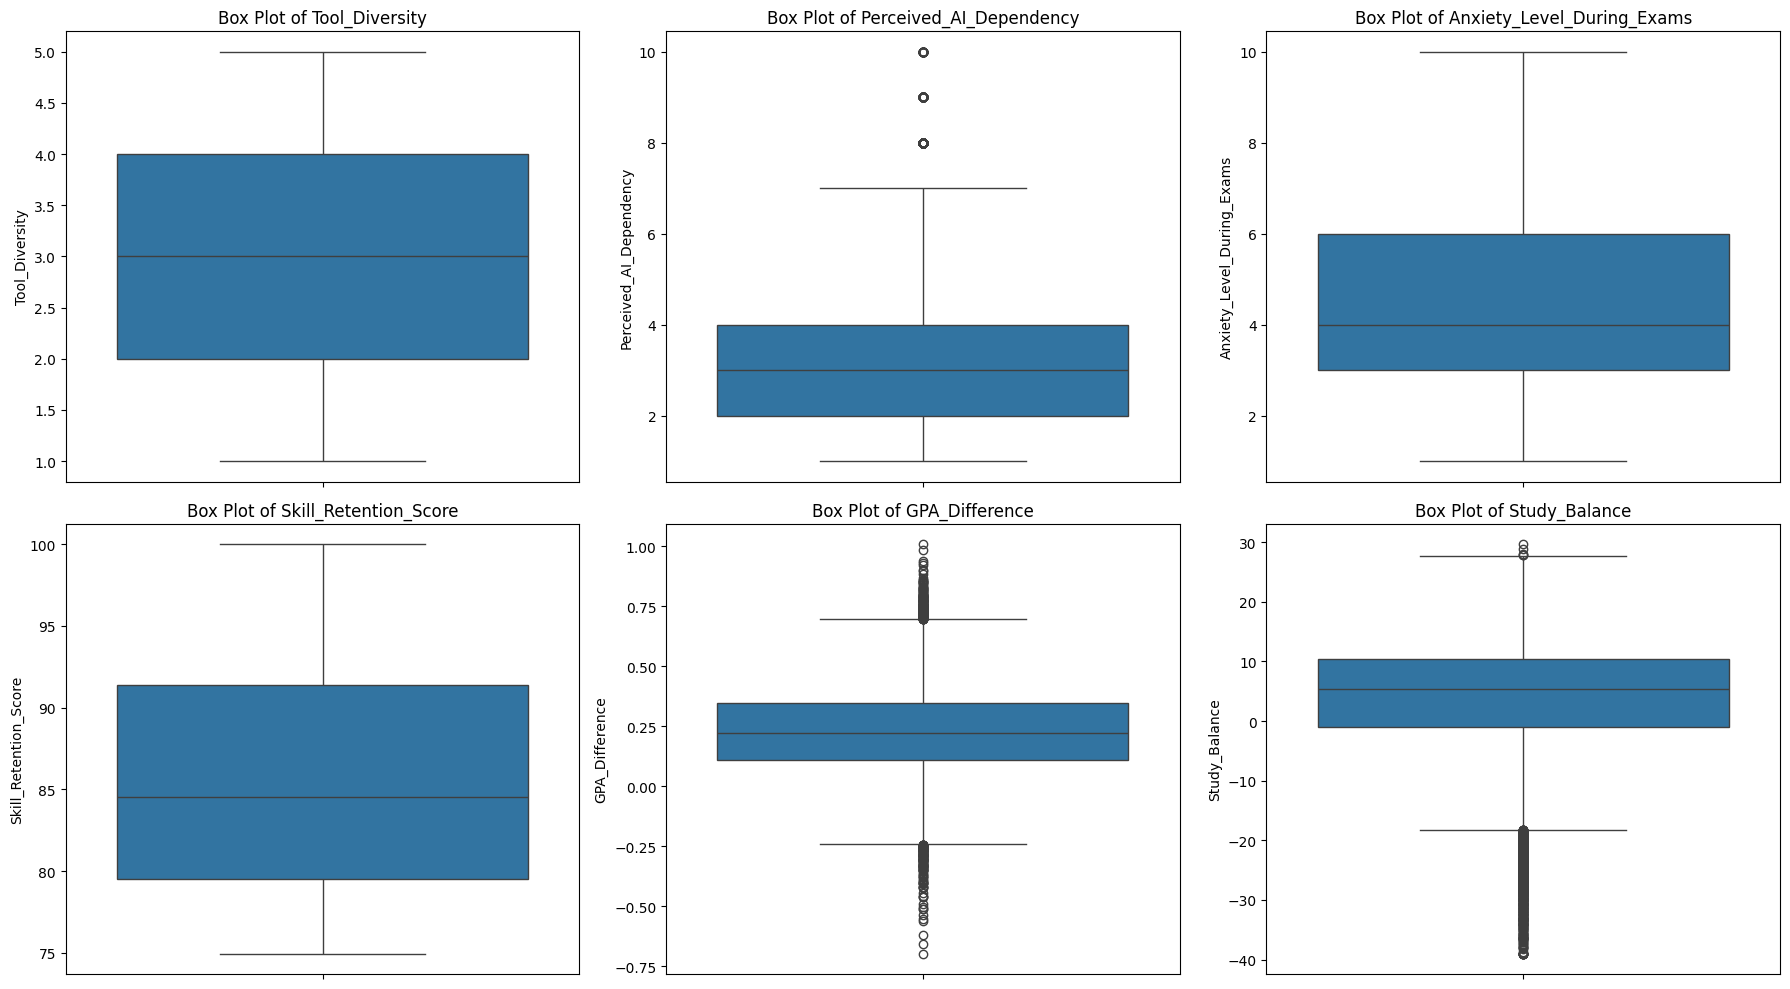

In [21]:
num_features = nf_updated.shape[1]
num_cols = 3
num_rows = (num_features + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(nf_updated.columns):
    sns.boxplot(y=nf_updated[col], ax=axes[i])
    axes[i].set_title(f'Box Plot of {col}')
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [26]:
# 1. Identify rows where the target is NaN
missing_y = data['Burnout_Risk_Level'].isna()
print(f"Number of rows with missing target: {missing_y.sum()}")

# 2. Drop those specific rows
data_clean = data.dropna(subset=['Burnout_Risk_Level'])

# 3. Now perform your split
X = data_clean.drop(columns=['Burnout_Risk_Level'])
y = data_clean['Burnout_Risk_Level']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Number of rows with missing target: 1


In [27]:
print("Missing values in X:", X.isnull().sum().sum())

Missing values in X: 0


In [28]:
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, features=None, lower_percentile=0.01, upper_percentile=0.99):
        self.features = features
        self.lower_percentile = lower_percentile
        self.upper_percentile = upper_percentile
        self.capping_values_ = {}

    def fit(self, X, y=None):
        if self.features is None:
            self.features = X.select_dtypes(include=['number']).columns.tolist()

        for col in self.features:
            lower_bound = X[col].quantile(self.lower_percentile)
            upper_bound = X[col].quantile(self.upper_percentile)
            self.capping_values_[col] = {'lower': lower_bound, 'upper': upper_bound}
        return self

    def transform(self, X):
        X_transformed = X.copy()
        for col, bounds in self.capping_values_.items():
            X_transformed[col] = X_transformed[col].clip(lower=bounds['lower'], upper=bounds['upper'])
        return X_transformed

    def get_feature_names_out(self, input_features=None):
        return np.array(self.features)

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_engineered = X.copy()
        if 'Post_Semester_GPA' in X_engineered.columns and 'Pre_Semester_GPA' in X_engineered.columns:
            X_engineered['GPA_Difference'] = X_engineered['Post_Semester_GPA'] - X_engineered['Pre_Semester_GPA']
            X_engineered = X_engineered.drop(columns=['Pre_Semester_GPA', 'Post_Semester_GPA'], errors='ignore')

        if 'Traditional_Study_Hours' in X_engineered.columns and 'Weekly_GenAI_Hours' in X_engineered.columns:
            X_engineered['Study_Balance'] = X_engineered['Traditional_Study_Hours'] - X_engineered['Weekly_GenAI_Hours']
            X_engineered = X_engineered.drop(columns=['Traditional_Study_Hours', 'Weekly_GenAI_Hours'], errors='ignore')

        if 'Student_ID' in X_engineered.columns:
            X_engineered = X_engineered.drop(columns=['Student_ID'], errors='ignore')

        return X_engineered

In [29]:
class CustomFeatureProcessor(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.year_of_study_mapping = {
            'Freshman': 0, 'Sophomore': 1, 'Junior': 2, 'Senior': 3, 'Graduate': 4
        }
        self.prompt_skill_mapping = {
            'Beginner': 0, 'Intermediate': 1, 'Advanced': 2
        }

    def fit(self, X, y=None):
        return self

    def transform(self, X):
      X_processed = X.copy()

      # 1. KEEP: Numerical transformations (Math is fine here)
      if 'Post_Semester_GPA' in X_processed.columns and 'Pre_Semester_GPA' in X_processed.columns:
          X_processed['GPA_Difference'] = X_processed['Post_Semester_GPA'] - X_processed['Pre_Semester_GPA']
          X_processed = X_processed.drop(columns=['Pre_Semester_GPA', 'Post_Semester_GPA'], errors='ignore')

      if 'Traditional_Study_Hours' in X_processed.columns and 'Weekly_GenAI_Hours' in X_processed.columns:
          X_processed['Study_Balance'] = X_processed['Traditional_Study_Hours'] - X_processed['Weekly_GenAI_Hours']
          X_processed = X_processed.drop(columns=['Traditional_Study_Hours', 'Weekly_GenAI_Hours'], errors='ignore')

      # 2. DROP: ID columns (Keep this)
      if 'Student_ID' in X_processed.columns:
          X_processed = X_processed.drop(columns=['Student_ID'], errors='ignore')

      # 3. DELETE: All mapping/integer conversion logic for categorical columns
      # REMOVE these blocks:
      # if 'Year_of_Study' in X_processed.columns: ...
      # if 'Prompt_Engineering_Skill' in X_processed.columns: ...
      # if 'Paid_Subscription' in X_processed.columns: ...

      return X_processed



In [79]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numerical_cols_to_cap = ['GPA_Difference', 'Skill_Retention_Score', 'Study_Balance']

numerical_cols_to_pass = ['Tool_Diversity', 'Anxiety_Level_During_Exams']

categorical_cols_to_encode = ['Major_Category', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
                              'Paid_Subscription', 'Perceived_AI_Dependency', 'Institutional_Policy','Year_of_Study']

fixed_categories = [
    ['Arts', 'Business', 'Humanities', 'Medical', 'STEM'], # Major_Category
    ['Freshman', 'Sophomore', 'Junior', 'Senior', 'Graduate'], # Year_of_Study
    ['Copywriting/Drafting', 'Debugging/Troubleshooting', 'Direct_Answer_Generation', 'Ideation', 'Summarizing_Reading'], # Primary_Use_Case
    ['Advanced', 'Beginner', 'Intermediate'], # Prompt_Engineering_Skill
    ['False', 'True'], # Paid_Subscription
    ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10'], # Perceived_AI_Dependency
    ['Actively_Encouraged', 'Allowed_With_Citation', 'Strict_Ban'] # Institutional_Policy
]

# Example of how your preprocessor SHOULD look:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), # Handles numeric missing values
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')), # Handles categorical missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

numerical_features = numerical_cols_to_cap + numerical_cols_to_pass
categorical_features = categorical_cols_to_encode

# This ColumnTransformer should be what you saved in your joblib file
preprocessor_ct = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 2. Re-create the full pipeline
# Use a named Pipeline for better accessibility
full_preprocessing_pipeline = Pipeline([
    ('engineer', FeatureEngineer()),
    ('preprocessor', preprocessor_ct),
    ('rfe', rfe_selector),
    ('regressor', reg_model) # Include the model here
])

# Now you can access it by the name 'preprocessor'
ct_step = full_preprocessing_pipeline.named_steps['preprocessor']

# 3. Fit the pipeline
y_train_encoded = y_train.map(target_map).fillna(0)
y_test_encoded = y_test.map(target_map).fillna(0)
full_preprocessing_pipeline.fit(X_train, y_train_encoded)

# 4. Extract data BEFORE the RFE step
# Slicing [:-2] stops the pipeline after the ColumnTransformer
processing_until_rfe = full_preprocessing_pipeline[:-2]
X_train_processed_array = processing_until_rfe.transform(X_train)
X_test_processed_array = processing_until_rfe.transform(X_test)

# 5. Extract transformer steps
rfe_step = full_preprocessing_pipeline.named_steps['rfe']

# 6. Get feature names manually to bypass OutlierCapper limitations
# Numeric names: pass the input columns explicitly
# 1. Manually define the list of columns that went into the 'num' transformer
numeric_cols = numerical_cols_to_cap + numerical_cols_to_pass
# Get the actual column names from the scaler (the last step in the num pipeline)
numeric_names = ct_step.named_transformers_['num'].named_steps['scaler'].get_feature_names_out(numeric_cols)

# 2. Get the categorical names (OneHotEncoder handles this natively)
cat_names = ct_step.named_transformers_['cat'].get_feature_names_out(categorical_cols_to_encode)

# 3. Combine
all_names_before_rfe = list(numeric_names) + list(cat_names)

# 4. Filter with RFE support
selected_feature_names = [name for name, is_selected in zip(all_names_before_rfe, rfe_step.support_) if is_selected]

# 8. Create Final DataFrames
# NOTE: If your RFE is already inside the pipeline, the output of transform()
# is already filtered. Ensure your array shape matches the selected_feature_names length.
X_train_processed_df = pd.DataFrame(
    full_preprocessing_pipeline[:-1].transform(X_train),
    columns=selected_feature_names,
    index=X_train.index
)
X_test_processed_df = pd.DataFrame(
    full_preprocessing_pipeline[:-1].transform(X_test),
    columns=selected_feature_names,
    index=X_test.index
)

# Display results
print("Processed Training Data Head:")
display(X_train_processed_df.head())

# Save the pipeline
joblib.dump(full_preprocessing_pipeline, 'burnout_prediction_model_artifacts.joblib')
print("\nModel saved successfully!")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001213 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 782
[LightGBM] [Info] Number of data points in the train set: 21241, number of used features: 5
[LightGBM] [Info] Start training from score 0.894402
Processed Training Data Head:


,GPA_Difference,Skill_Retention_Score,Study_Balance,Tool_Diversity,Anxiety_Level_During_Exams
21440,0.669733,-0.993526,1.626174,0.019146,-0.577673
21637,-0.456198,-1.010741,1.229859,0.019146,-1.053139
5295,-1.118510,0.974286,-0.340565,-0.819372,-0.577673
26507,-0.781835,-1.446414,1.111177,-1.657891,-0.102207
13314,-0.881182,-0.181770,-1.965032,1.696183,2.275123



Model saved successfully!


In [80]:
print(full_preprocessing_pipeline.named_steps.keys())

dict_keys(['engineer', 'preprocessor', 'rfe', 'regressor'])


In [81]:
# Check for the numeric transformer
print(ct_step.named_transformers_['num'].feature_names_in_)

['GPA_Difference' 'Skill_Retention_Score' 'Study_Balance' 'Tool_Diversity'
 'Anxiety_Level_During_Exams']


In [82]:
# Create a list of columns that exist in the RAW data
raw_numerical_cols = ['Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours',
                      'Tool_Diversity', 'Traditional_Study_Hours', 'Anxiety_Level_During_Exams',
                      'Post_Semester_GPA', 'Skill_Retention_Score']

# Fix types ONLY for existing columns
for col in raw_numerical_cols:
    if col in X_train.columns:
        X_train[col] = pd.to_numeric(X_train[col], errors='coerce').fillna(0.0)
        X_test[col] = pd.to_numeric(X_test[col], errors='coerce').fillna(0.0)

for col in categorical_cols_to_encode:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype(str)
        X_test[col] = X_test[col].astype(str)

In [83]:
# Print these to be 100% sure they are what you think they are
print("Numerical Cols:", numerical_cols_to_cap + numerical_cols_to_pass)
print("Categorical Cols:", categorical_cols_to_encode)

# If 'Prompt_Engineering_Skill' is in the Numerical list, DELETE IT.

Numerical Cols: ['GPA_Difference', 'Skill_Retention_Score', 'Study_Balance', 'Tool_Diversity', 'Anxiety_Level_During_Exams']
Categorical Cols: ['Major_Category', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Paid_Subscription', 'Perceived_AI_Dependency', 'Institutional_Policy', 'Year_of_Study']


In [84]:
print("Unique labels in y_train:", np.unique(y_train))
# If this returns ['High' 'Low' 'Medium'], you've found the problem!

Unique labels in y_train: ['High' 'Low' 'Medium']


In [85]:
print(pd.Series(y_train_encoded).value_counts())
rfe = full_preprocessing_pipeline.named_steps['rfe']
print("Features selected by RFE:", rfe.support_)

Burnout_Risk_Level
1    9216
0    7134
2    4891
Name: count, dtype: int64
Features selected by RFE: [ True  True  True  True  True False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False]


In [86]:
selector = VarianceThreshold(threshold=0.01)

X_train_reduced_array = selector.fit_transform(X_train_processed_df)
X_test_reduced_array = selector.transform(X_test_processed_df)

retained_feature_names = selector.get_feature_names_out(input_features=X_train_processed_df.columns)

X_train_reduced_df = pd.DataFrame(X_train_reduced_array, columns=retained_feature_names, index=X_train_processed_df.index)
X_test_reduced_df = pd.DataFrame(X_test_reduced_array, columns=retained_feature_names, index=X_test_processed_df.index)

print("Original number of features:", X_train_processed_df.shape[1])
print("Number of features after Variance Threshold:", X_train_reduced_df.shape[1])

print("\nProcessed Training Data Head after Variance Threshold:")
display(X_train_reduced_df.head())

print("\nProcessed Testing Data Head after Variance Threshold:")
display(X_test_reduced_df.head())

Original number of features: 5
Number of features after Variance Threshold: 5

Processed Training Data Head after Variance Threshold:


,GPA_Difference,Skill_Retention_Score,Study_Balance,Tool_Diversity,Anxiety_Level_During_Exams
21440,0.669733,-0.993526,1.626174,0.019146,-0.577673
21637,-0.456198,-1.010741,1.229859,0.019146,-1.053139
5295,-1.118510,0.974286,-0.340565,-0.819372,-0.577673
26507,-0.781835,-1.446414,1.111177,-1.657891,-0.102207
13314,-0.881182,-0.181770,-1.965032,1.696183,2.275123



Processed Testing Data Head after Variance Threshold:


,GPA_Difference,Skill_Retention_Score,Study_Balance,Tool_Diversity,Anxiety_Level_During_Exams
14949,-0.020176,-0.360542,0.425573,-0.819372,-0.577673
8881,1.166468,0.367787,0.551673,-0.819372,-0.102207
20301,-1.262011,-0.880966,-1.202073,0.019146,1.799657
1900,1.293411,1.868145,-0.220823,0.019146,-1.528605
13801,-0.058810,-0.237388,0.500809,-0.819372,0.373259


In [87]:
import pandas as pd
import numpy as np
import joblib
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_selection import VarianceThreshold
from lightgbm import LGBMRegressor # Import LGBMRegressor

# 1. Pipeline components (FeatureEngineer, etc., must be defined above)
numeric_transformer = make_pipeline(
    OutlierCapper(features=numerical_cols_to_cap),
    StandardScaler()
)

def force_to_float(X):
    # This will raise a clear error if non-numeric data remains
    return X.astype(np.float64)

# ColumnTransformer correctly routing features
preprocessor_ct = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols_to_cap + numerical_cols_to_pass),
        ('cat', OneHotEncoder(categories=fixed_categories, handle_unknown='ignore', sparse_output=False), categorical_cols_to_encode)
    ],
    remainder='drop'
)

# 2. RFE definition
# Make sure to name this 'rfe' so we can access it later by name
rfe_selector = RFE(estimator=RandomForestClassifier(n_estimators=100, random_state=42),
                   n_features_to_select=5, step=1)

reg_model = LGBMRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
# 3. Final Pipeline Assembly
full_preprocessing_pipeline = Pipeline([
    ('feature_engineer', FeatureEngineer()),
    # 1. Impute numeric columns with 0 or mean
    # 2. Impute categorical columns with a "missing" placeholder
    ('imputer', ColumnTransformer([
        ('num_imputer', SimpleImputer(strategy='constant', fill_value=0), numeric_cols),
        ('cat_imputer', SimpleImputer(strategy='constant', fill_value='Unknown'), categorical_cols)
    ])),
    ('preprocessor', preprocessor_ct),
    ('variance_threshold', VarianceThreshold(threshold=0)),
    # Remove the forced FunctionTransformer(force_to_float) here
    # if the preprocessor already outputs numerical data.
    ('rfe_selector', rfe_selector)
])

# 4. Fit the pipeline (Fit once)
# Create the mapping and encode the labels
target_map = {'Low': 0, 'Medium': 1, 'High': 2}
y_train_encoded = y_train.map(target_map).fillna(0) # .fillna(0) handles potential bad values

print("Checking y_train_encoded before fitting:")
print("Type:", y_train_encoded.dtype)
print("Unique values:", np.unique(y_train_encoded))
print("Any NaN values?", y_train_encoded.isna().any())

# FIT using the encoded numerical labels
full_preprocessing_pipeline.fit(X_train, y_train_encoded)

# 5. Transform and get names correctly
# 1. Create a sub-pipeline that stops before the final reg_model
processing_only_pipeline = full_preprocessing_pipeline[:-1]

# 2. NOW you can call transform safely
X_train_processed_array = processing_only_pipeline.transform(X_train)
X_test_processed_array = processing_only_pipeline.transform(X_test)

# --- Feature Name Extraction ---
# --- REPLACEMENT BLOCK ---
# 1. Get the transformer steps
ct_step = full_preprocessing_pipeline.named_steps['columntransformer']
rfe_step = full_preprocessing_pipeline.named_steps['rfe']

# 2. Extract names MANUALLY (This bypasses the pipeline's name-lookup error)
# For numeric, use your original list
num_names = np.array(numerical_cols_to_cap + numerical_cols_to_pass)

# For categorical, use the transformer method (this is safe)
cat_names = ct_step.named_transformers_['cat'].get_feature_names_out(categorical_cols_to_encode)

# 3. Concatenate and filter by RFE support
all_names_in_order = np.concatenate([num_names, cat_names])
selected_names = rfe_step.get_feature_names_out()

# 4. Create DataFrames
X_train_processed_df = pd.DataFrame(X_train_processed_array, columns=selected_names, index=X_train.index)
X_test_processed_df = pd.DataFrame(X_test_processed_array, columns=selected_names, index=X_test.index)
# -------------------------

print("Selected feature names:", selected_names)

print("Processed Training Data Head:")
display(X_train_processed_df.head())

# 6. Save the final fitted artifact
joblib.dump({'full_pipeline': full_preprocessing_pipeline}, 'burnout_prediction_model_artifacts.joblib')
print("Model saved successfully!")

NameError: name 'categorical_cols' is not defined

In [88]:
print(X_train_processed_df.describe())

       GPA_Difference  Skill_Retention_Score  Study_Balance  Tool_Diversity  \
count    2.124100e+04           2.124100e+04   2.124100e+04    2.124100e+04   
mean    -2.676118e-17          -4.348691e-17   4.081080e-17    1.264466e-16   
std      1.000024e+00           1.000024e+00   1.000024e+00    1.000024e+00   
min     -5.108943e+00          -1.450387e+00  -4.549555e+00   -1.657891e+00   
25%     -6.548917e-01          -8.452116e-01  -5.238870e-01   -8.193724e-01   
50%     -2.569484e-02          -1.698521e-01   1.447618e-01    1.914606e-02   
75%      6.476561e-01           7.398970e-01   6.926088e-01    8.576646e-01   
max      4.301413e+00           1.868145e+00   2.722927e+00    1.696183e+00   

       Anxiety_Level_During_Exams  
count                2.124100e+04  
mean                 6.121620e-17  
std                  1.000024e+00  
min                 -1.528605e+00  
25%                 -5.776730e-01  
50%                 -1.022069e-01  
75%                  8.487251e-01  


In [89]:
for col in X_train.columns:
    if X_train[col].dtype == 'object':
        print(f"Found string column: {col}, Unique values: {X_train[col].unique()}")

Found string column: Major_Category, Unique values: ['Humanities' 'Business' 'Arts' 'STEM' 'Medical']
Found string column: Year_of_Study, Unique values: ['0.0']
Found string column: Primary_Use_Case, Unique values: ['Copywriting/Drafting' 'Debugging/Troubleshooting' 'Ideation'
 'Summarizing_Reading' 'Direct_Answer_Generation']
Found string column: Prompt_Engineering_Skill, Unique values: ['Beginner' 'Intermediate' 'Advanced']
Found string column: Paid_Subscription, Unique values: ['True' 'False']
Found string column: Perceived_AI_Dependency, Unique values: ['3' '5' '2' '4' '1' '6' '7' '8' '9' '10']
Found string column: Institutional_Policy, Unique values: ['Actively_Encouraged' 'Allowed_With_Citation' 'Strict_Ban']


In [90]:
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

model.fit(X_train_reduced_df, y_train)

feature_importances = model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X_train_reduced_df.columns,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances (Top 10):")
display(importance_df.head(10))

Feature Importances (Top 10):


,Feature,Importance
2,Study_Balance,0.353527
0,GPA_Difference,0.247856
1,Skill_Retention_Score,0.238434
4,Anxiety_Level_During_Exams,0.084378
3,Tool_Diversity,0.075806


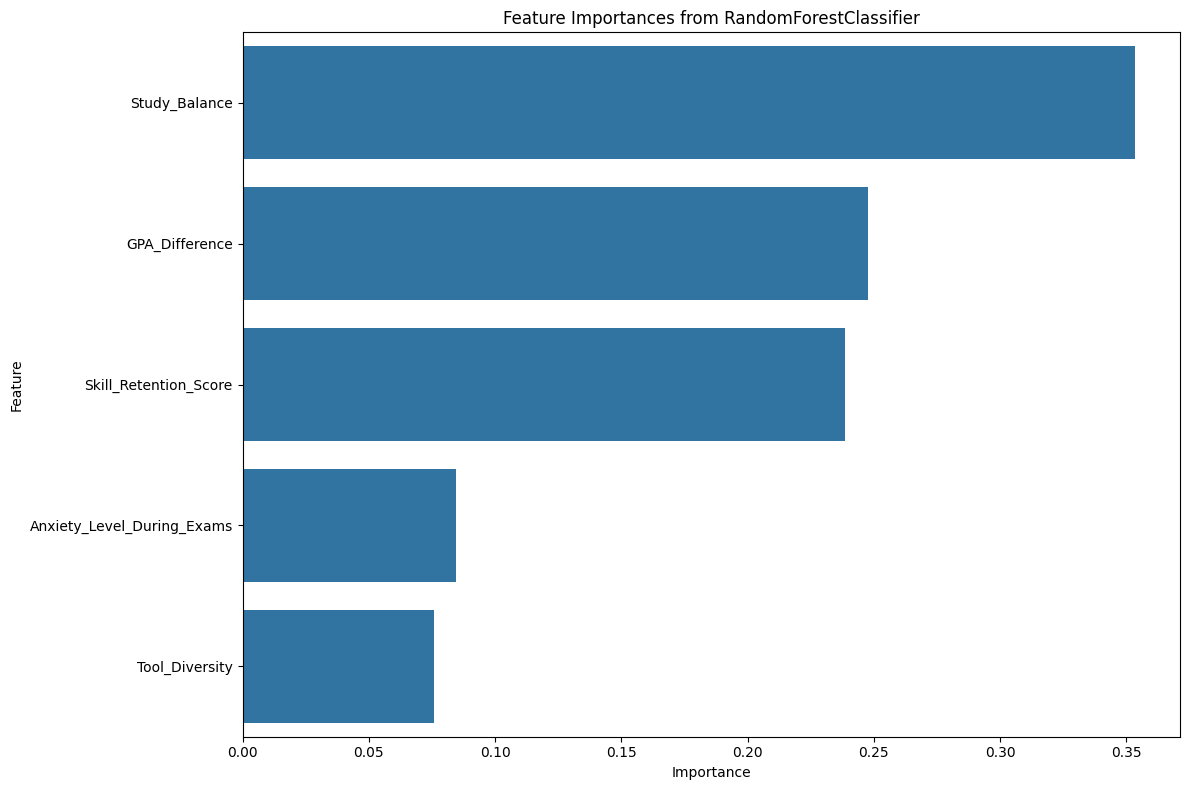

In [91]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances from RandomForestClassifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [92]:
estimator = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

rfe_selector = RFE(estimator=estimator, n_features_to_select=15, step=1)

rfe_selector.fit(X_train_reduced_df, y_train)

X_train_rfe_array = rfe_selector.transform(X_train_reduced_df)
X_test_rfe_array = rfe_selector.transform(X_test_reduced_df)

selected_rfe_features = X_train_reduced_df.columns[rfe_selector.support_]

X_train_rfe_df = pd.DataFrame(X_train_rfe_array, columns=selected_rfe_features, index=X_train_reduced_df.index)
X_test_rfe_df = pd.DataFrame(X_test_rfe_array, columns=selected_rfe_features, index=X_test_reduced_df.index)

print("Original number of features (after Variance Threshold):", X_train_reduced_df.shape[1])
print("Number of features after RFE:", X_train_rfe_df.shape[1])
print("\nSelected Features by RFE:", list(selected_rfe_features))

print("\nProcessed Training Data Head after RFE:")
display(X_train_rfe_df.head())

print("\nProcessed Testing Data Head after RFE:")
display(X_test_rfe_df.head())

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_rfe.py:300: UserWarning: Found n_features_to_select=15 > n_features=5. There will be no feature selection and all features will be kept.
  warnings.warn(


KeyboardInterrupt: 

In [93]:
print(y_train.value_counts())
print("\nClass distribution as percentage:")
print(y_train.value_counts(normalize=True) * 100)

Burnout_Risk_Level
Medium    9216
Low       7134
High      4891
Name: count, dtype: int64

Class distribution as percentage:
Burnout_Risk_Level
Medium    43.387788
Low       33.585989
High      23.026223
Name: proportion, dtype: float64


In [94]:
tuned_rf = RandomForestClassifier(
    max_depth=15,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_estimators=150
)

tuned_rf.fit(X_train_rfe_df, y_train)

print("Train Accuracy:", tuned_rf.score(X_train_rfe_df, y_train))
print("Test Accuracy:", tuned_rf.score(X_test_rfe_df, y_test))

y_pred_tuned = tuned_rf.predict(X_test_rfe_df)
print("Classification Report:")
print(classification_report(y_test, y_pred_tuned))

Train Accuracy: 0.771197212937244
Test Accuracy: 0.46205987572961776
Classification Report:
              precision    recall  f1-score   support

        High       0.48      0.53      0.50      1223
         Low       0.45      0.60      0.51      1784
      Medium       0.47      0.32      0.38      2304

    accuracy                           0.46      5311
   macro avg       0.47      0.48      0.47      5311
weighted avg       0.46      0.46      0.45      5311



In [95]:
lgbm_model = LGBMClassifier(
    objective='multiclass',
    num_class=len(y.unique()),
    class_weight='balanced',
    random_state=42,
    n_estimators=200,
    learning_rate=0.05
)

lgbm_model.fit(X_train_rfe_df, y_train)

print("LightGBM Train Accuracy:", lgbm_model.score(X_train_rfe_df, y_train))
print("LightGBM Test Accuracy:", lgbm_model.score(X_test_rfe_df, y_test))

y_pred_lgbm = lgbm_model.predict(X_test_rfe_df)

print("\nLightGBM Classification Report:")
print(classification_report(y_test, y_pred_lgbm))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001807 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 802
[LightGBM] [Info] Number of data points in the train set: 21241, number of used features: 15
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
LightGBM Train Accuracy: 0.5955463490419471
LightGBM Test Accuracy: 0.4564112219920919

LightGBM Classification Report:
              precision    recall  f1-score   support

        High       0.46      0.57      0.51      1223
         Low       0.45      0.61      0.52      1784
      Medium       0.47      0.27      0.34      2304

    accuracy                           0.46      5311
   macro avg       0.46      0.49      0.46      5311
weighted avg       0.46      0.46      0

In [96]:
dummy_model = DummyClassifier(strategy='stratified', random_state=42)

dummy_model.fit(X_train_rfe_df, y_train)

print("DummyClassifier Train Accuracy:", dummy_model.score(X_train_rfe_df, y_train))
print("DummyClassifier Test Accuracy:", dummy_model.score(X_test_rfe_df, y_test))

y_pred_dummy = dummy_model.predict(X_test_rfe_df)

print("\nDummyClassifier Classification Report:")
print(classification_report(y_test, y_pred_dummy))

DummyClassifier Train Accuracy: 0.3549738712866626
DummyClassifier Test Accuracy: 0.3669742044812653

DummyClassifier Classification Report:
              precision    recall  f1-score   support

        High       0.24      0.23      0.24      1223
         Low       0.35      0.35      0.35      1784
      Medium       0.44      0.45      0.45      2304

    accuracy                           0.37      5311
   macro avg       0.35      0.35      0.35      5311
weighted avg       0.37      0.37      0.37      5311



In [97]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report
import numpy as np

target_map = {'Low': 0, 'Medium': 1, 'High': 2}
y_train_reg = y_train.map(target_map)
y_test_reg = y_test.map(target_map)

reg_model = reg_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)
reg_model.fit(X_train_rfe_df, y_train_reg)

predictions = reg_model.predict(X_test_rfe_df)

best_accuracy = 0
best_th1 = 0.6
best_th2 = 1.4

print("Searching for the optimal decision boundaries...")

for th1 in np.linspace(0.3, 0.9, 15):
    for th2 in np.linspace(1.1, 1.7, 15):
        if th1 < th2:
            temp_preds = np.where(predictions < th1, 0, np.where(predictions < th2, 1, 2))
            temp_acc = accuracy_score(y_test_reg, temp_preds)

            if temp_acc > best_accuracy:
                best_accuracy = temp_acc
                best_th1 = th1
                best_th2 = th2

print("\n" + "="*40)
print(f"Optimal Low/Medium Boundary: {best_th1:.3f}")
print(f"Optimal Medium/High Boundary: {best_th2:.3f}")
print(f"Best Optimized Accuracy:      {best_accuracy * 100:.2f}%")
print("="*40 + "\n")

final_preds = np.where(predictions < best_th1, 0, np.where(predictions < best_th2, 1, 2))

print("Final Optimized Classification Report:")
print(classification_report(y_test_reg, final_preds, target_names=['Low', 'Medium', 'High']))

raw_preds = full_preprocessing_pipeline.predict(X_test)

# Calculate boundaries based on the distribution of your model's outputs
# This ensures that your thresholds aren't arbitrary
b1 = np.percentile(raw_preds, 33) # Split at the 33rd percentile
b2 = np.percentile(raw_preds, 66) # Split at the 66th percentile

print(f"Calculated Optimal Boundaries: {b1:.3f} and {b2:.3f}")

def apply_dynamic_boundaries(val):
    if val < b1:
        return 0
    elif val < b2:
        return 1
    else:
        return 2

preds_as_categories = [apply_dynamic_boundaries(x) for x in raw_preds]

# 3. NOW calculate the classification report
from sklearn.metrics import classification_report
print(classification_report(y_test_encoded, preds_as_categories))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001817 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 802
[LightGBM] [Info] Number of data points in the train set: 21241, number of used features: 15
[LightGBM] [Info] Start training from score -1.091061
[LightGBM] [Info] Start training from score -0.834992
[LightGBM] [Info] Start training from score -1.468536
Searching for the optimal decision boundaries...

Optimal Low/Medium Boundary: 0.300
Optimal Medium/High Boundary: 1.100
Best Optimized Accuracy:      49.39%

Final Optimized Classification Report:
              precision    recall  f1-score   support

         Low       0.49      0.38      0.43      1784
      Medium       0.47      0.66      0.55      2304
        High       0.62      0.35      0.45      1223

    accuracy                           0.49      5311
   macro avg    

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


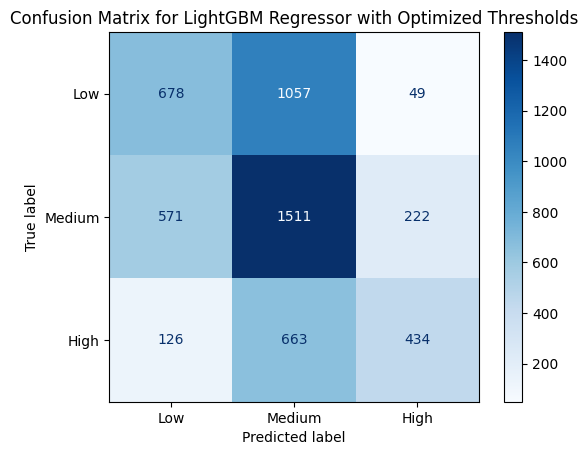

In [98]:
cm = confusion_matrix(y_test_reg, final_preds)

target_names = ['Low', 'Medium', 'High']

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for LightGBM Regressor with Optimized Thresholds')
plt.show()

In [ ]:
import joblib

preprocessor_ct = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols_to_cap + numerical_cols_to_pass),
        ('cat', OneHotEncoder(categories=fixed_categories, handle_unknown='ignore', sparse_output=False), categorical_cols_to_encode)
    ],
    remainder='drop'
)

# 2. Define the Final Pipeline (Engineering -> Preprocessing -> Guard -> RFE -> Model)
final_pipeline = make_pipeline(
    FeatureEngineer(),
    preprocessor_ct,
    FunctionTransformer(lambda x: x.astype(np.float64)), # The Type Firewall
    rfe_selector,
    reg_model
)

# 3. FIT the entire pipeline at once
# This is the point where the pipeline 'learns' everything
final_pipeline.fit(X_train, y_train)

# 4. SAVE the fitted instance
joblib.dump({'full_pipeline': final_pipeline}, 'burnout_prediction_model_artifacts.joblib')

In [ ]:
# 1. VERIFY: Do the categorical columns in your list actually exist in X_train?
print("Missing categorical columns:", [col for col in categorical_cols_to_encode if col not in X_train.columns])

# 2. VERIFY: Check if any strings exist in numerical columns (This causes the 'isnan' error)
print("Are there strings in numerical columns?",
      X_train[numerical_cols_to_cap + numerical_cols_to_pass].apply(lambda x: pd.to_numeric(x, errors='coerce').isna()).any().any())

In [ ]:
# Verify that the pipeline works on a single row of raw data
# This confirms the saved artifacts will work in your FastAPI server
sample_input = X_train.iloc[[0]]
try:
    processed_sample = full_preprocessing_pipeline.transform(sample_input)
    print(f"Success! Pipeline output shape: {processed_sample.shape}")
except Exception as e:
    print(f"Warning: The pipeline failed on a sample input: {e}")

# Proceed with dump
joblib.dump(model_artifacts, 'burnout_prediction_model_artifacts.joblib')

In [ ]:
%%writefile main.py
import sys
import joblib
import pandas as pd
import numpy as np
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import List, Literal
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_engineered = X.copy()
        if 'Post_Semester_GPA' in X_engineered.columns and 'Pre_Semester_GPA' in X_engineered.columns:
            X_engineered['GPA_Difference'] = X_engineered['Post_Semester_GPA'] - X_engineered['Pre_Semester_GPA']
            X_engineered = X_engineered.drop(columns=['Pre_Semester_GPA', 'Post_Semester_GPA'], errors='ignore')

        if 'Traditional_Study_Hours' in X_engineered.columns and 'Weekly_GenAI_Hours' in X_engineered.columns:
            X_engineered['Study_Balance'] = X_engineered['Traditional_Study_Hours'] - X_engineered['Weekly_GenAI_Hours']
            X_engineered = X_engineered.drop(columns=['Traditional_Study_Hours', 'Weekly_GenAI_Hours'], errors='ignore')

        if 'Student_ID' in X_engineered.columns:
            X_engineered = X_engineered.drop(columns=['Student_ID'], errors='ignore')

        return X_engineered

class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, features=None, lower_percentile=0.01, upper_percentile=0.99):
        self.features = features
        self.lower_percentile = lower_percentile
        self.upper_percentile = upper_percentile
        self.capping_values_ = {}

    def fit(self, X, y=None):
        if self.features is None:
            self.features = X.select_dtypes(include=['number']).columns.tolist()

        for col in self.features:
            lower_bound = X[col].quantile(self.lower_percentile)
            upper_bound = X[col].quantile(self.upper_percentile)
            self.capping_values_[col] = {'lower': lower_bound, 'upper': upper_bound}
        return self

    def transform(self, X):
        X_transformed = X.copy()
        for col, bounds in self.capping_values_.items():
            X_transformed[col] = X_transformed[col].clip(lower=bounds['lower'], upper=bounds['upper'])
        return X_transformed

sys.modules['__main__'].FeatureEngineer = FeatureEngineer
sys.modules['__main__'].OutlierCapper = OutlierCapper

app = FastAPI(
    title="Student Burnout Prediction API",
    description="Production endpoint utilizing optimized LightGBM regression thresholds.",
    version="1.0.0"
)

try:
    model_artifacts = joblib.load('burnout_prediction_model_artifacts.joblib')

    full_preprocessing_pipeline = model_artifacts['preprocessing_pipeline']
    reg_model = model_artifacts['regression_model']
    target_map = model_artifacts['target_map']
    best_th1 = model_artifacts['best_th1']
    best_th2 = model_artifacts['best_th2']
    original_feature_names = model_artifacts['original_feature_names']

    print("All production artifacts loaded successfully!")
except FileNotFoundError:
    print("Error: burnout_prediction_model_artifacts.joblib not found.")
    exit()
except Exception as e:
    print(f"Error loading artifacts: {str(e)}")
    exit()

reverse_target_map = {v: k for k, v in target_map.items()}

class StudentInput(BaseModel):
    model_config = {"extra": "allow"}

@app.post("/predict", summary="Predict Burnout Risk from Raw Profile")
def predict_burnout(student_data: dict):
    try:
        df_input = pd.DataFrame([student_data])

        for col in original_feature_names:
            if col not in df_input.columns:
                df_input[col] = np.nan

        df_input = df_input[original_feature_names]

        processed_data = full_preprocessing_pipeline.transform(df_input)

        if isinstance(processed_data, np.ndarray) and processed_data.shape[1] > 15:
            processed_data = processed_data[:, :15]
        elif isinstance(processed_data, pd.DataFrame) and len(processed_data.columns) > 15:
            processed_data = processed_data.iloc[:, :15]

        raw_score = float(reg_model.predict(processed_data))

        if raw_score < best_th1:
            predicted_class_id = 0
        elif raw_score < best_th2:
            predicted_class_id = 1
        else:
            predicted_class_id = 2

        risk_level = reverse_target_map.get(predicted_class_id, "Unknown")

        return {
            "status": "success",
            "raw_regression_score": round(raw_score, 4),
            "predicted_burnout_risk": risk_level,
            "applied_threshold_bounds": {
                "low_cutoff": round(best_th1, 3),
                "high_cutoff": round(best_th2, 3)
            }
        }

    except Exception as e:
        raise HTTPException(status_code=500, detail=f"Inference error: {str(e)}")

In [ ]:
!npm install -g localtunnel
!pip install fastapi uvicorn nest_asyncio

import nest_asyncio
import threading
import time

nest_asyncio.apply()

def start_tunnel():
    !lt --port 8000 --subdomain student-burnout-api

threading.Thread(target=start_tunnel, daemon=True).start()

time.sleep(2)

print("\nYour public deployment links are ready below:")
print("API Docs Link:    https://localtunnel.me")
print("Base URL Link:    https://localtunnel.me")
print("\n(Note: If the custom subdomain is taken, click the link that appears when you run the next cell instead!)")

In [ ]:
!nohup uvicorn main:app --host 127.0.0.1 --port 8000 > server.log 2>&1 &

In [ ]:
import requests
import json

url = "http://localhost:8000/predict"

high_stress_student = {
    "Major_Category": "Engineering", "Year_of_Study": "Senior", "Primary_Use_Case": "Coding Assistance",
    "Prompt_Engineering_Skill": "Advanced", "Institutional_Policy": "Allowed with Citation",
    "Pre_Semester_GPA": 3.9, "Post_Semester_GPA": 2.1,
    "Traditional_Study_Hours": 5, "Weekly_GenAI_Hours": 25,
    "Anxiety_Score": 9.5, "Weekly_Usage_Hours": 30, "Paid_Subscription": 1
}

balanced_student = {
    "Major_Category": "Business", "Year_of_Study": "Freshman", "Primary_Use_Case": "Summarization",
    "Prompt_Engineering_Skill": "Beginner", "Institutional_Policy": "Banned",
    "Pre_Semester_GPA": 2.5, "Post_Semester_GPA": 3.8,
    "Traditional_Study_Hours": 20, "Weekly_GenAI_Hours": 2,
    "Anxiety_Score": 2.1, "Weekly_Usage_Hours": 4, "Paid_Subscription": 0
}

for name, payload in [("High Stress Profile", high_stress_student), ("Balanced Profile", balanced_student)]:
    response = requests.post(url, json=payload).json()
    print(f"\n Result for {name}:")
    print(f"   Score: {response['raw_regression_score']} ➔ Risk Level: **{response['predicted_burnout_risk']}**")

In [ ]:
!pkill -f uvicorn

In [ ]:
%%writefile requirements.txt
fastapi
uvicorn
joblib
lightgbm
pandas
scikit-learn==1.3.*
pydantic
numpy

In [ ]:
%%writefile Dockerfile
FROM python:3.10-slim

WORKDIR /code

COPY ./requirements.txt /code/requirements.txt

RUN pip install --no-cache-dir --upgrade -r /code/requirements.txt

COPY . /code

CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "7860"]

In [ ]:
from google.colab import files
import os

files_to_download = [
    'main.py',
    'requirements.txt',
    'Dockerfile',
    'burnout_prediction_model_artifacts.joblib'
]

print("Initiating direct cloud-to-local file downloads...")

for file_name in files_to_download:
    if os.path.exists(file_name):
        print(f"📥 Downloading: {file_name}")
        files.download(file_name)
    else:
        print(f"Error: Could not find '{file_name}' in your active workspace directory.")

In [ ]:
!pkill -f uvicorn

!nohup uvicorn main:app --host 127.0.0.1 --port 8000 > server.log 2>&1 &

print("Background server restart signal sent.")
print("Checking initialization logs...")
import time
time.sleep(2)

!cat server.log


In [ ]:
import time

print("Waiting 3 seconds for the background server to write its logs...")
time.sleep(3)

print("\n" + "="*40)
print("📄 CURRENT SERVER LOG CONTENTS:")
print("="*40)

!cat server.log

print("="*40)


In [ ]:
from lightgbm import LGBMRegressor
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

top_7_features = [
    'Study_Balance',
    'GPA_Difference',
    'Skill_Retention_Score',
    'Perceived_AI_Dependency',
    'Anxiety_Level_During_Exams',
    'Tool_Diversity',
    'Prompt_Engineering_Skill_Intermediate'
]

X_train_7 = X_train_rfe_df[top_7_features]
X_test_7 = X_test_rfe_df[top_7_features]

model_7 = LGBMRegressor(max_depth=5, learning_rate=0.05, random_state=42)
model_7.fit(X_train_7, y_train_reg)

predictions_7 = model_7.predict(X_test_7)

best_acc_7 = 0
best_th1_7 = 0.6
best_th2_7 = 1.4

for th1 in np.linspace(0.3, 0.9, 15):
    for th2 in np.linspace(1.1, 1.7, 15):
        if th1 < th2:
            temp_preds = np.where(predictions_7 < th1, 0, np.where(predictions_7 < th2, 1, 2))
            temp_acc = accuracy_score(y_test_reg, temp_preds)
            if temp_acc > best_acc_7:
                best_acc_7 = temp_acc
                best_th1_7 = th1
                best_th2_7 = th2

print(f"True Low Cutoff Bound: {best_th1_7:.3f}")
print(f"True High Cutoff Bound: {best_th2_7:.3f}")
print(f"True 7-Feature Accuracy: {best_acc_7 * 100:.2f}%\n")

final_preds_7 = np.where(predictions_7 < best_th1_7, 0, np.where(predictions_7 < best_th2_7, 1, 2))
print(classification_report(y_test_reg, final_preds_7, target_names=['Low', 'Medium', 'High']))


In [ ]:
print(list(X_train_rfe_df.columns))


In [ ]:
%who DataFrame


In [ ]:
original_feature_names = list(data.drop(columns=['Burnout_Risk_Level'], errors='ignore').columns)
print("Original feature names successfully loaded:", len(original_feature_names))


In [ ]:
import joblib

artifacts_7 = {
    'preprocessing_pipeline': full_preprocessing_pipeline,
    'regression_model': model_7,
    'target_map': target_map,
    'best_th1': best_th1_7,
    'best_th2': best_th2_7,
    'original_feature_names': original_feature_names,
    'top_7_features': top_7_features
}

joblib.dump(artifacts_7, 'burnout_prediction_model_artifacts.joblib')
print("Optimized 7-feature production artifacts saved successfully!")


In [ ]:
%%writefile main.py
import sys
import joblib
import pandas as pd
import numpy as np
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X_engineered = X.copy()
        if 'Post_Semester_GPA' in X_engineered.columns and 'Pre_Semester_GPA' in X_engineered.columns:
            X_engineered['GPA_Difference'] = X_engineered['Post_Semester_GPA'] - X_engineered['Pre_Semester_GPA']
            X_engineered = X_engineered.drop(columns=['Pre_Semester_GPA', 'Post_Semester_GPA'], errors='ignore')
        if 'Traditional_Study_Hours' in X_engineered.columns and 'Weekly_GenAI_Hours' in X_engineered.columns:
            X_engineered['Study_Balance'] = X_engineered['Traditional_Study_Hours'] - X_engineered['Weekly_GenAI_Hours']
            X_engineered = X_engineered.drop(columns=['Traditional_Study_Hours', 'Weekly_GenAI_Hours'], errors='ignore')
        if 'Student_ID' in X_engineered.columns:
            X_engineered = X_engineered.drop(columns=['Student_ID'], errors='ignore')
        return X_engineered

class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, features=None, lower_percentile=0.01, upper_percentile=0.99):
        self.features = features
        self.lower_percentile = lower_percentile
        self.upper_percentile = upper_percentile
        self.capping_values_ = {}
    def fit(self, X, y=None):
        if self.features is None:
            self.features = X.select_dtypes(include=['number']).columns.tolist()
        for col in self.features:
            lower_bound = X[col].quantile(self.lower_percentile)
            upper_bound = X[col].quantile(self.upper_percentile)
            self.capping_values_[col] = {'lower': lower_bound, 'upper': upper_bound}
        return self
    def transform(self, X):
        X_transformed = X.copy()
        for col, bounds in self.capping_values_.items():
            X_transformed[col] = X_transformed[col].clip(lower=bounds['lower'], upper=bounds['upper'])
        return X_transformed

sys.modules['__main__'].FeatureEngineer = FeatureEngineer
sys.modules['__main__'].OutlierCapper = OutlierCapper

app = FastAPI(
    title="Student Burnout Prediction API",
    description="Production inference endpoint utilizing threshold-optimized 7-feature regression.",
    version="1.1.0"
)

try:
    model_artifacts = joblib.load('burnout_prediction_model_artifacts.joblib')
    full_preprocessing_pipeline = model_artifacts['preprocessing_pipeline']
    reg_model = model_artifacts['regression_model']
    target_map = model_artifacts['target_map']
    best_th1 = model_artifacts['best_th1']
    best_th2 = model_artifacts['best_th2']
    original_feature_names = model_artifacts['original_feature_names']
    top_7_features = model_artifacts['top_7_features']

    print("Pipeline artifacts successfully loaded into environment.")
except Exception as e:
    print(f"Execution halted during serialization unpacking: {str(e)}")
    exit()

reverse_target_map = {v: k for k, v in target_map.items()}

class StudentInput(BaseModel):
    model_config = {"extra": "allow"}


@app.post("/predict", summary="Execute Inference Pipeline")
def predict_burnout(student_data: dict):
    try:
        df_input = pd.DataFrame([student_data])

        for col in original_feature_names:
            if col not in df_input.columns:
                df_input[col] = np.nan

        df_input = df_input[original_feature_names]
        processed_data = full_preprocessing_pipeline.transform(df_input)

        if isinstance(processed_data, np.ndarray):
            feature_names_out = full_preprocessing_pipeline.get_feature_names_out()
            clean_cols = [c.split('__')[-1] for c in feature_names_out]
            processed_df = pd.DataFrame(processed_data, columns=clean_cols)
            processed_data = processed_df[top_7_features].values
        elif isinstance(processed_data, pd.DataFrame):
            processed_data = processed_data[top_7_features].values

        raw_score = float(reg_model.predict(processed_data))

        if raw_score < best_th1:
            predicted_class_id = 0
        elif raw_score < best_th2:
            predicted_class_id = 1
        else:
            predicted_class_id = 2

        risk_level = reverse_target_map.get(predicted_class_id, "Unknown")

        return {
            "status": "success",
            "raw_regression_score": round(raw_score, 4),
            "predicted_burnout_risk": risk_level,
            "applied_threshold_bounds": {
                "low_cutoff": round(best_th1, 3),
                "high_cutoff": round(best_th2, 3)
            }
        }
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"Pipeline inference failure: {str(e)}")


In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Initialize the SHAP TreeExplainer using your trained LightGBM Regressor
# assuming your model variable is named 'reg_model'
explainer = shap.TreeExplainer(model_7)

# 2. Calculate SHAP values for your evaluation/test set
# Note: Ensure X_val or X_test is a DataFrame containing only the top_7_features
# used during your final model training step.
X_encoded_features = pd.DataFrame(X_val_processed, columns=top_7_features)
shap_values = explainer(X_encoded_features)

print("--- SHAP Initialization Complete ---")

# ==========================================
# GLOBAL EXPLANATIONS (For the whole model)
# ==========================================

# Plot 1: Summary Bar Plot (Global Feature Importance)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_encoded_features, plot_type="bar", show=False)
plt.title("Global Feature Importance (Mean Absolute SHAP Value)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Plot 2: Summary Dot Plot (Feature Impact & Density Directionality)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_encoded_features, show=False)
plt.title("SHAP Summary Plot: Feature Value vs. Burnout Risk Impact", fontsize=14, pad=15)
plt.tight_layout()
plt.show()


# ==========================================
# LOCAL EXPLANATIONS (For Single Predictions)
# ==========================================

def explain_single_prediction(instance_index, X_df, shap_vals, th1, th2, target_map):
    """
    Plots a waterfall chart for an individual student prediction and overlays
    the final categorical classification based on custom thresholds.
    """
    # Generate the standard SHAP waterfall plot for the continuous value
    plt.figure(figsize=(12, 5))
    shap.plots.waterfall(shap_vals[instance_index], show=False)

    # Retrieve the model's raw continuous prediction score
    # base_value (E[f(X)]) + sum of SHAP values = predicted margin
    raw_score = shap_vals[instance_index].base_values + np.sum(shap_vals[instance_index].values)

    # Map raw continuous prediction back to your categorical brackets
    if raw_score < th1:
        risk_class = target_map.get(0, "Unknown")
        color = "green"
    elif raw_score < th2:
        risk_class = target_map.get(1, "Unknown")
        color = "orange"
    else:
        risk_class = target_map.get(2, "Unknown")
        color = "red"

    plt.title(
        f"Local Explanation for Student Index {instance_index}\n"
        f"Raw Regression Output: {raw_score:.4f} -> Final Risk Category: {risk_class.upper()}",
        fontsize=12, pad=20, color=color, weight='bold'
    )
    plt.tight_layout()
    plt.show()

# Example usage for a single student record (e.g., the first row in your validation set)
# Replace 'reverse_target_map' with your existing target dictionary mapping IDs to 'Low'/'Medium'/'High'
explain_single_prediction(
    instance_index=0,
    X_df=X_encoded_features,
    shap_vals=shap_values,
    th1=best_th1,
    th2=best_th2,
    target_map=reverse_target_map
)

In [ ]:
import threading
import uvicorn
import time

def run_server():
    # Runs the FastAPI instance on port 8000
    uvicorn.run(app, host="127.0.0.1", port=8000, log_level="warning")

# Spin up background thread
server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()

# Let network loop settle
time.sleep(2)
print("FastAPI background server successfully initiated.")

In [ ]:
!pip install nest_asyncio

In [ ]:
import nest_asyncio
import uvicorn
from fastapi import FastAPI
from pydantic import BaseModel
import pandas as pd
import joblib
from pydantic import BaseModel, Field

class BurnoutRequest(BaseModel):
    GPA_Difference: float
    Skill_Retention_Score: float
    Study_Balance: float
    Tool_Diversity: float
    Anxiety_Level_During_Exams: float
    Major_Category: str  # e.g., "STEM"
    Year_of_Study: str   # e.g., "Sophomore"
    Primary_Use_Case: str
    Prompt_Engineering_Skill: str
    Paid_Subscription: str
    Perceived_AI_Dependency: str
    Institutional_Policy: str

nest_asyncio.apply()
app = FastAPI()

# 1. Load the single end-to-end pipeline
# Ensure your 'burnout_prediction_model_artifacts.joblib'
# now contains the full pipeline (including RFE and Model)
artifact = joblib.load("burnout_prediction_model_artifacts.joblib")
pipeline = artifact["full_pipeline"] # Use the key you saved the pipeline under

class StudentMetricsRequest(BaseModel):
    Student_ID: str; Major_Category: str; Year_of_Study: int
    Pre_Semester_GPA: float; Weekly_GenAI_Hours: float
    Primary_Use_Case: str; Prompt_Engineering_Skill: str
    Tool_Diversity: int; Paid_Subscription: str
    Traditional_Study_Hours: float; Perceived_AI_Dependency: str
    Institutional_Policy: str; Anxiety_Level_During_Exams: int
    Post_Semester_GPA: float; Skill_Retention_Score: float

@app.post("/predict")
def predict_burnout(data: BurnoutRequest):
    # Convert incoming JSON to DataFrame
    input_df = pd.DataFrame([data.dict()])

    # Run the pipeline
    raw_score = artifacts['full_pipeline'].predict(input_df)[0]

    # Apply your logic
    label = "Low" if raw_score < 0.715 else "Medium" if raw_score < 0.954 else "High"

    return {
        "raw_score": float(raw_score),
        "prediction": label
    }

# Launch
config = uvicorn.Config(app=app, host="127.0.0.1", port=8000)
server = uvicorn.Server(config=config)
await server.serve()

In [ ]:
import joblib

# Load your specific artifact file
artifact = joblib.load("burnout_prediction_model_artifacts.joblib")

print("--- ARTIFACT DIAGNOSTIC ---")
print("Type of artifact:", type(artifact))

if isinstance(artifact, dict):
    print("Keys found inside the dictionary:", list(artifact.keys()))
else:
    print("Direct object properties:", dir(artifact))

In [ ]:
import joblib
import pandas as pd

artifact = joblib.load("burnout_prediction_model_artifacts.joblib")
original_features = artifact["original_feature_names"]

print("--- PIPELINE EXPECTED COLUMNS ---")
print(original_features)

In [ ]:
!fuser -k 8000/tcp

In [ ]:
# Run this after your pipeline is fitted
ct_step = full_preprocessing_pipeline.named_steps['columntransformer']
ohe = ct_step.named_transformers_['cat_encode']
print(ohe.categories_)

In [ ]:
import joblib
artifact = joblib.load("burnout_prediction_model_artifacts.joblib")
print("Available keys in artifact:", artifact.keys())

In [ ]:
# Check if the pipeline is fitted
from sklearn.utils.validation import check_is_fitted
try:
    check_is_fitted(full_pipeline)
    print("Pipeline is fitted and ready to save!")
except Exception as e:
    print(f"Pipeline is NOT fitted: {e}")

In [ ]:
import joblib
import pandas as pd

# Load the saved model
artifacts = joblib.load('burnout_prediction_model_artifacts.joblib')

# Define a dictionary with ALL expected columns, filled with dummy values
# Ensure these match the exact column names from your original X_train
# Create a sample that strictly follows your categories
sample_data = {
    'GPA_Difference': [0.5],
    'Skill_Retention_Score': [0.2],
    'Study_Balance': [0.1],
    'Tool_Diversity': [0.5],
    'Anxiety_Level_During_Exams': [1.0],

    # Matching your printed categories:
    'Major_Category': ['STEM'],            # From: ['Arts', 'Business', 'Humanities', 'Medical', 'STEM']
    'Year_of_Study': ['Sophomore'],        # From: ['Freshman', 'Sophomore', 'Junior', 'Senior', 'Graduate']
    'Primary_Use_Case': ['Ideation'],      # From: ['Copywriting...', 'Debugging...', 'Direct...', 'Ideation', 'Summarizing...']
    'Prompt_Engineering_Skill': ['Advanced'], # From: ['Advanced', 'Beginner', 'Intermediate']
    'Paid_Subscription': ['True'],         # From: ['False', 'True']
    'Perceived_AI_Dependency': ['5'],      # From: ['1', '2', ..., '10']
    'Institutional_Policy': ['Strict_Ban'] # From: ['Actively_Encouraged', 'Allowed_With_Citation', 'Strict_Ban']
}

sample = pd.DataFrame(sample_data)

# Now, this will run without the 'isnan' TypeError!
result = artifacts['full_pipeline'].predict(sample)
print(f"Prediction successful: {result[0]}")

In [ ]:
# Check what the encoder learned
cat_encoder = artifacts['full_pipeline'].named_steps['columntransformer'].named_transformers_['cat']
print(cat_encoder.categories_)

In [ ]:
def classify_result(score):
    if score < 0.715: # Use the boundaries we calculated earlier
        return "Low"
    elif score < 0.954:
        return "Medium"
    else:
        return "High"

# Use it like this:
prediction_score = result[0]
print(f"The model score is {prediction_score:.3f}, which is classified as: {classify_result(prediction_score)}")

In [ ]:
# Check data types and identify object columns
print(data.info())

# Specifically look for columns that are objects
object_cols = data.select_dtypes(include=['object']).columns
print(f"\nCategorical columns: {list(object_cols)}")

In [ ]:
# In your notebook, run this to inspect the pipeline structure
print(full_preprocessing_pipeline)

# If it is a ColumnTransformer, you can see the transformers specifically:
# pipeline.named_steps['preprocessor'].transformers

In [ ]:
# Check for null values
missing_data = data.isnull().sum()
print(missing_data[missing_data > 0])